# Modelo de priorización de renovación urbana en Bogotá mediante análisis espacial, clustering no supervisado y scoring multicriterio

Este notebook documenta el proceso de análisis exploratorio de datos y modelación no supervisada desarrollado para identificar y priorizar manzanas con potencial de renovación urbana dentro de las actuaciones estratégicas del Plan de Ordenamiento Territorial (POT) de Bogotá.

El objetivo del análisis es construir una herramienta analítica que permita integrar variables urbanas, demográficas y de accesibilidad con el fin de apoyar procesos de planificación territorial orientados a la renovación urbana.

La metodología implementada combina análisis exploratorio de datos, reducción de dimensionalidad mediante Análisis de Componentes Principales (PCA), identificación de tipologías urbanas mediante clustering no supervisado (K-Means) y la construcción de un índice de priorización de renovación urbana basado en múltiples variables territoriales.

Los resultados permiten identificar patrones territoriales en la estructura urbana y establecer una clasificación de manzanas según su potencial de intervención.

Este análisis fue desarrollado como parte del proyecto de investigación:

**“Modelo de priorización de renovación urbana en Bogotá mediante análisis espacial y aprendizaje automático”.**

Especialización en Estadística Aplicada  
Fundación Universitaria Los Libertadores  
Bogotá, Colombia

## Estructura del análisis

Carga y revisión del dataset
Evaluación de calidad de datos
Aplicación de filtros normativos del POT
Análisis exploratorio de variables urbanas
Normalización de variables
Identificación de clusters mediante K-Means
Interpretación de tipologías urbanas
Construcción del índice de priorización de renovación urbana
Clasificación de manzanas según nivel de prioridad
Exportación de resultados para análisis geoespacial

LIBRERÍAS

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

CARGAR ARCHIVO

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
df = pd.read_excel("manzanas_ae.xlsx")

In [11]:
df = pd.read_excel("manzanas_ae.xlsx")
df.head()

,objectid,man_codigo,actuacion_estrategica,ae_priorizada,cod_dane,area_manzana,densidad,viviendas,poblacion,dist_tm,...,viviendas_desocupadas,tiene_parque,tiene_equipa_pub,tiene_esp_pub,tiene_aim,plan_parcial_excluido,estado_pp,tiene_bic,sum_exclusiones,calificables
0,1,8544012,Lagos de Torca,0,1100110000000085330115,9850.528979,0.048472,190.0,492.0,211.750049,...,1.0,0.0,0.0,0.0,0.0,0.0,Ninguno,0.0,0.0,1.0
1,2,8519059,Nodo Toberin,0,1100110000000085190312,3952.997481,0.013165,20.0,52.0,826.160220,...,2.0,0.0,0.0,0.0,0.0,0.0,Ninguno,0.0,0.0,1.0
2,3,8516029,Nodo Toberin,0,1100110000000085160107,6712.437990,0.027434,50.0,184.0,773.151617,...,2.0,0.0,0.0,0.0,0.0,0.0,Ninguno,0.0,0.0,1.0
3,4,8516019,Nodo Toberin,0,1100110000000085160201,21563.511592,0.038000,325.0,822.0,567.918018,...,6.0,0.0,0.0,0.0,0.0,0.0,Ninguno,0.0,0.0,1.0
4,5,8501008,Nodo Toberin,0,1100110000000085010206,17517.294260,0.005901,47.0,100.0,238.909162,...,0.0,0.0,0.0,0.0,0.0,0.0,Ninguno,0.0,0.0,1.0


REVISIÓN BÁSICA DEL DATASET

## 1. Carga y estructura del dataset

En esta sección se revisa la estructura general del conjunto de datos, incluyendo número de observaciones, variables y tipos de datos.

In [12]:
df.isnull().sum()

,0
objectid,0
man_codigo,0
actuacion_estrategica,0
ae_priorizada,0
cod_dane,166
area_manzana,0
densidad,166
viviendas,166
poblacion,166
dist_tm,166


In [13]:
total_manzanas = len(df)
manzanas_con_nulos = df.isnull().any(axis=1).sum()
porcentaje_nulos = manzanas_con_nulos / total_manzanas * 100

print(f"Total de manzanas: {total_manzanas}")
print(f"Manzanas con al menos un valor nulo: {manzanas_con_nulos}")
print(f"Porcentaje de manzanas con nulos: {porcentaje_nulos:.2f}%")

Total de manzanas: 3400
Manzanas con al menos un valor nulo: 166
Porcentaje de manzanas con nulos: 4.88%


### Interpretación de valores faltantes

Los valores nulos identificados corresponden principalmente a manzanas que no presentaron correspondencia espacial en el cruce con información censal del DANE u otras variables derivadas. Estas observaciones se excluyen del análisis posterior para garantizar consistencia en los procesos de normalización, PCA y clustering.

In [14]:
df = df.dropna().copy()
print("Dimensiones después de eliminar nulos:", df.shape)

Dimensiones después de eliminar nulos: (3234, 25)


## 3. Cobertura de información censal

La variable `cantidad_encuestas` representa el número de observaciones censales asociadas a cada manzana. Aunque no se incorpora directamente al modelo de clustering, es útil para evaluar la cobertura y representatividad de la información derivada del cruce con el DANE.

In [15]:
df["cantidad_encuestas"].describe()

,cantidad_encuestas
count,3234.000000
mean,57.861163
std,68.015352
min,0.000000
25%,22.000000
50%,44.000000
75%,72.000000
max,1040.000000


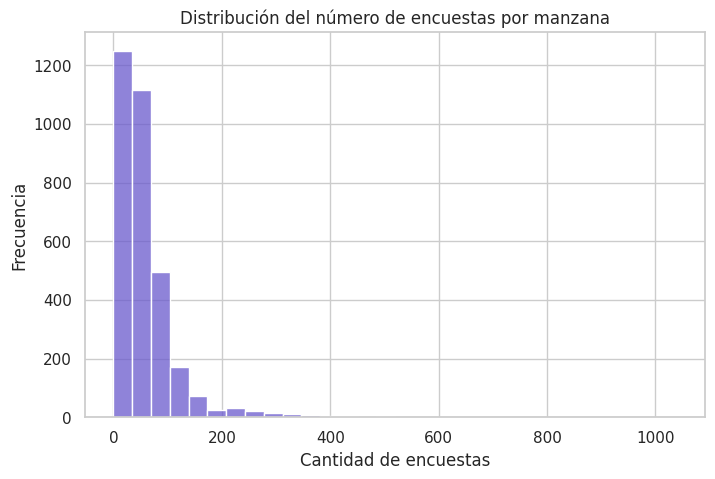

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df["cantidad_encuestas"], bins=30, color="slateblue")
plt.title("Distribución del número de encuestas por manzana")
plt.xlabel("Cantidad de encuestas")
plt.ylabel("Frecuencia")
plt.show()

### Interpretación de `cantidad_encuestas`

La distribución de `cantidad_encuestas` permite identificar la cobertura censal de las manzanas analizadas. Valores bajos pueden indicar menor soporte de información, mientras que valores altos reflejan mayor cantidad de observaciones asociadas a la manzana. Esta variable no se utiliza en el clustering, pero sí aporta contexto sobre la calidad de la información disponible.

ANALISIS NORMATIVO

## 4. Análisis normativo y filtro de exclusiones

Antes de la modelación se analizan las variables normativas, ya que estas permiten excluir manzanas que no pueden ser objeto de procesos de renovación urbana según el POT y otras restricciones urbanísticas.

In [17]:
df["calificables"].value_counts()

,count
calificables,
1.0,2228
0.0,1006


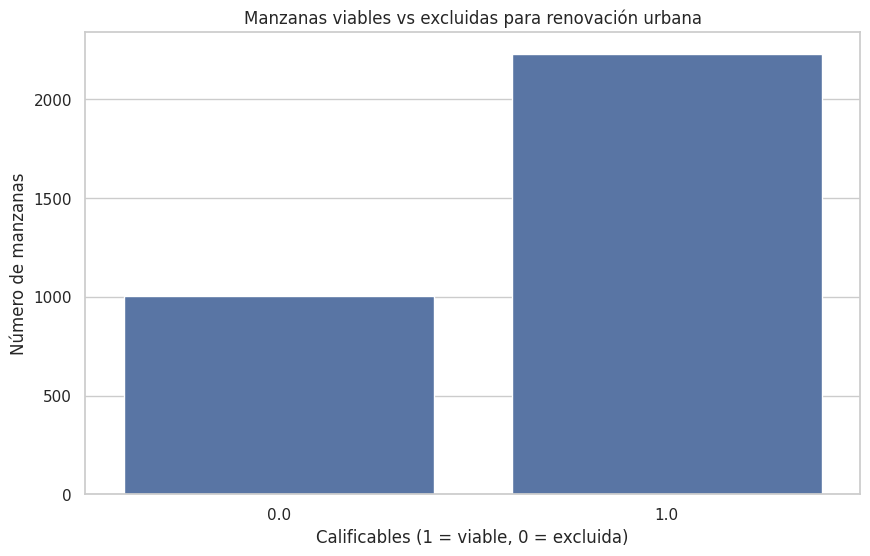

In [18]:
sns.countplot(x="calificables", data=df)
plt.title("Manzanas viables vs excluidas para renovación urbana")
plt.xlabel("Calificables (1 = viable, 0 = excluida)")
plt.ylabel("Número de manzanas")
plt.show()

In [19]:
cols_normativas = [
    "tiene_parque",
    "tiene_equipa_pub",
    "tiene_esp_pub",
    "tiene_aim",
    "plan_parcial_excluido",
    "tiene_bic"
]

df[cols_normativas].sum().sort_values(ascending=False)

,0
tiene_parque,441.0
tiene_aim,240.0
tiene_equipa_pub,202.0
tiene_bic,155.0
plan_parcial_excluido,105.0
tiene_esp_pub,25.0


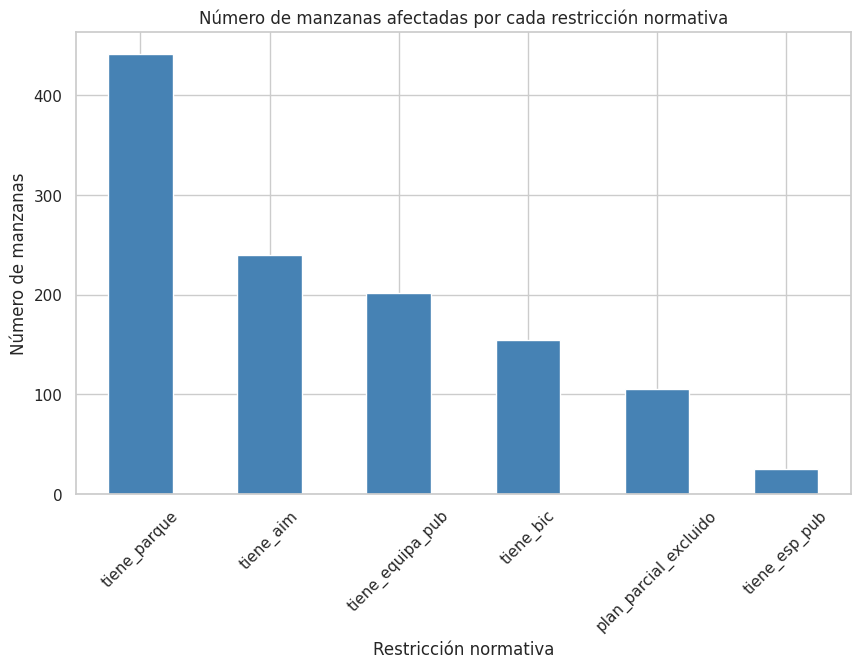

In [20]:
causas_exclusion = df[cols_normativas].sum().sort_values(ascending=False)

causas_exclusion.plot(kind="bar", color="steelblue")
plt.title("Número de manzanas afectadas por cada restricción normativa")
plt.xlabel("Restricción normativa")
plt.ylabel("Número de manzanas")
plt.xticks(rotation=45)
plt.show()

### Interpretación del análisis normativo

Las variables normativas no se incorporan directamente al modelo de clustering, pero sí son fundamentales para construir el filtro urbano previo. Estas variables permiten excluir manzanas que no pueden ser objeto de renovación urbana por restricciones como presencia de parques, equipamientos, espacio público, áreas de interés ambiental, planes parciales vigentes o bienes de interés cultural.

FILTRAR MANZANAS VIABLES

In [21]:
df_modelo = df[df["calificables"] == 1].copy()
print("Dimensiones del dataset para modelación:", df_modelo.shape)

Dimensiones del dataset para modelación: (2228, 25)


VARIABLES DEL MODELO

## 5. Selección de variables urbanas para análisis

Se utilizan variables urbanas y demográficas que permiten caracterizar intensidad urbana, accesibilidad, estructura física de la manzana y vacancia residencial.

In [22]:
variables = [
    "area_manzana",
    "densidad",
    "viviendas",
    "poblacion",
    "dist_tm",
    "mix_uso",
    "viviendas_desocupadas"
]

variables

['area_manzana',
 'densidad',
 'viviendas',
 'poblacion',
 'dist_tm',
 'mix_uso',
 'viviendas_desocupadas']

### Nota sobre la variable `mix_uso`

La variable `mix_uso` se construyó como la suma de unidades no residenciales con uso comercial e industrial. Por esta razón, no representa un índice clásico de mezcla de usos del suelo, sino un indicador proxy de actividad económica no residencial en la manzana.

Esta variable se incorpora al análisis con el fin de capturar la presencia de funciones económicas urbanas que pueden incidir en el potencial de transformación del territorio.

DESCRIPTIVOS URBANOS

In [23]:
df_modelo[variables].describe().round(3)

,area_manzana,densidad,viviendas,poblacion,dist_tm,mix_uso,viviendas_desocupadas
count,2228.000,2228.000,2228.000,2228.00,2228.000,2228.000,2228.000
mean,6443.119,0.045,48.119,135.73,459.182,6.403,2.089
std,16463.472,0.040,51.549,137.04,594.588,8.489,4.296
min,119.998,0.000,0.000,0.00,0.000,0.000,0.000
25%,2059.153,0.011,19.000,49.00,202.006,1.000,0.000
50%,3592.836,0.035,38.000,112.00,325.295,3.000,1.000
75%,6245.571,0.075,63.000,188.25,567.967,9.000,3.000
max,478727.446,0.198,901.000,2561.00,5172.947,62.000,95.000


HISTOGRAMAS

## 6. Distribución de variables urbanas

Se analiza la distribución de las variables urbanas mediante histogramas, con el fin de identificar sesgos, concentraciones y comportamientos extremos.

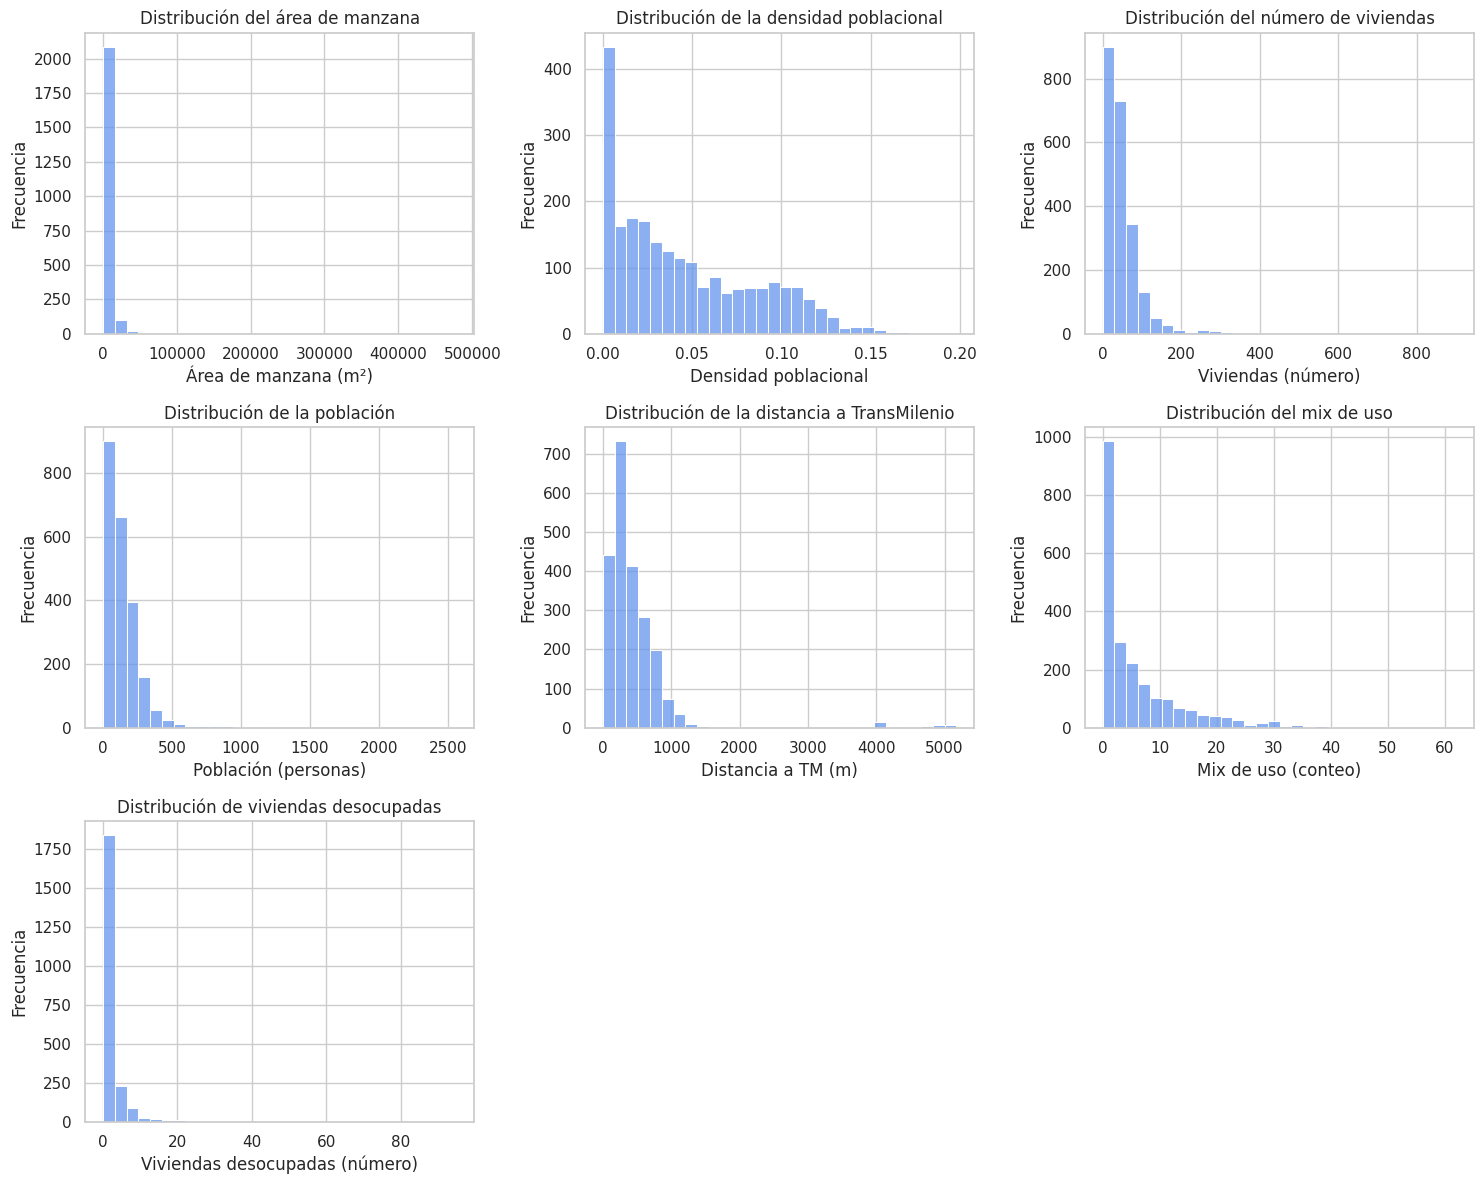

In [24]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

graficos = [
    ("area_manzana", "Distribución del área de manzana", "Área de manzana (m²)"),
    ("densidad", "Distribución de la densidad poblacional", "Densidad poblacional"),
    ("viviendas", "Distribución del número de viviendas", "Viviendas (número)"),
    ("poblacion", "Distribución de la población", "Población (personas)"),
    ("dist_tm", "Distribución de la distancia a TransMilenio", "Distancia a TM (m)"),
    ("mix_uso", "Distribución del mix de uso", "Mix de uso (conteo)"),
    ("viviendas_desocupadas", "Distribución de viviendas desocupadas", "Viviendas desocupadas (número)")
]

for i, (var, titulo, xlabel) in enumerate(graficos):
    sns.histplot(df_modelo[var], bins=30, ax=axes[i], color="cornflowerblue")
    axes[i].set_title(titulo)
    axes[i].set_xlabel(xlabel)
    axes[i].set_ylabel("Frecuencia")

for j in range(len(graficos), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

BOXPLOT

## 7. Detección de valores atípicos

Se usan diagramas de caja para identificar valores extremos y evaluar la dispersión de las variables urbanas.

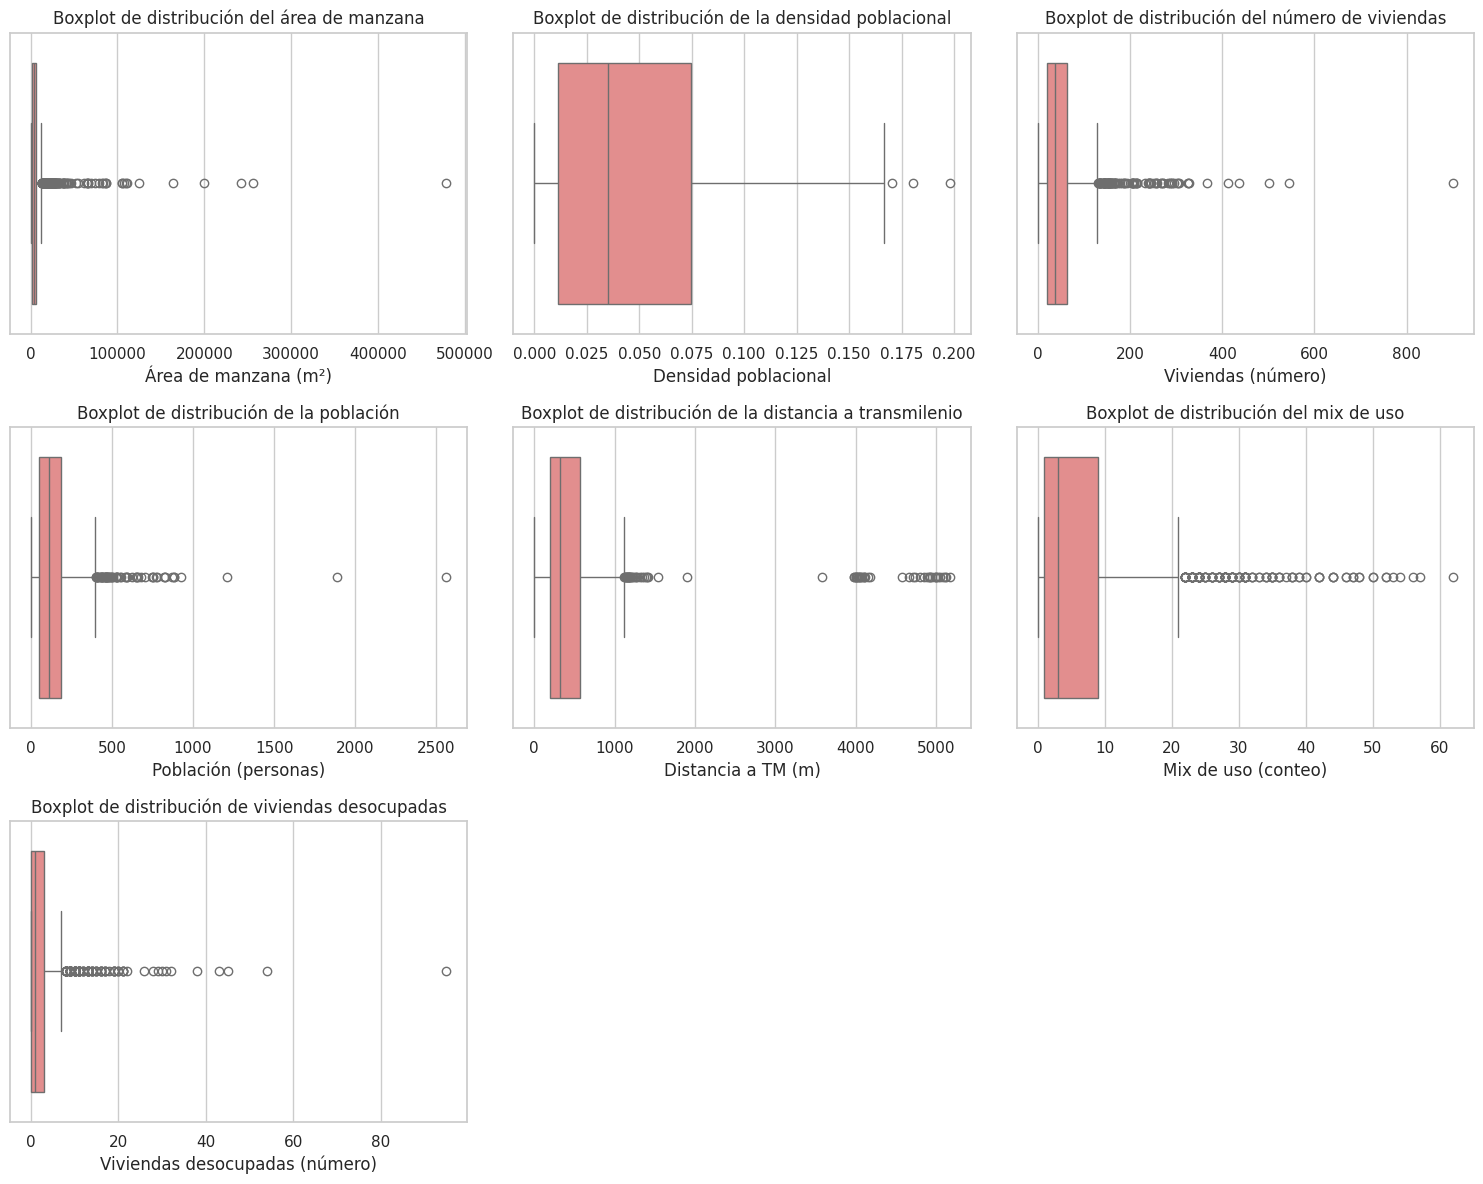

In [25]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, (var, titulo, xlabel) in enumerate(graficos):
    sns.boxplot(x=df_modelo[var], ax=axes[i], color="lightcoral")
    axes[i].set_title(f"Boxplot de {titulo.lower()}")
    axes[i].set_xlabel(xlabel)

for j in range(len(graficos), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

CORRELACION

## 8. Relación entre variables urbanas

Se calcula una matriz de correlación para identificar relaciones lineales entre variables y justificar la aplicación de PCA.

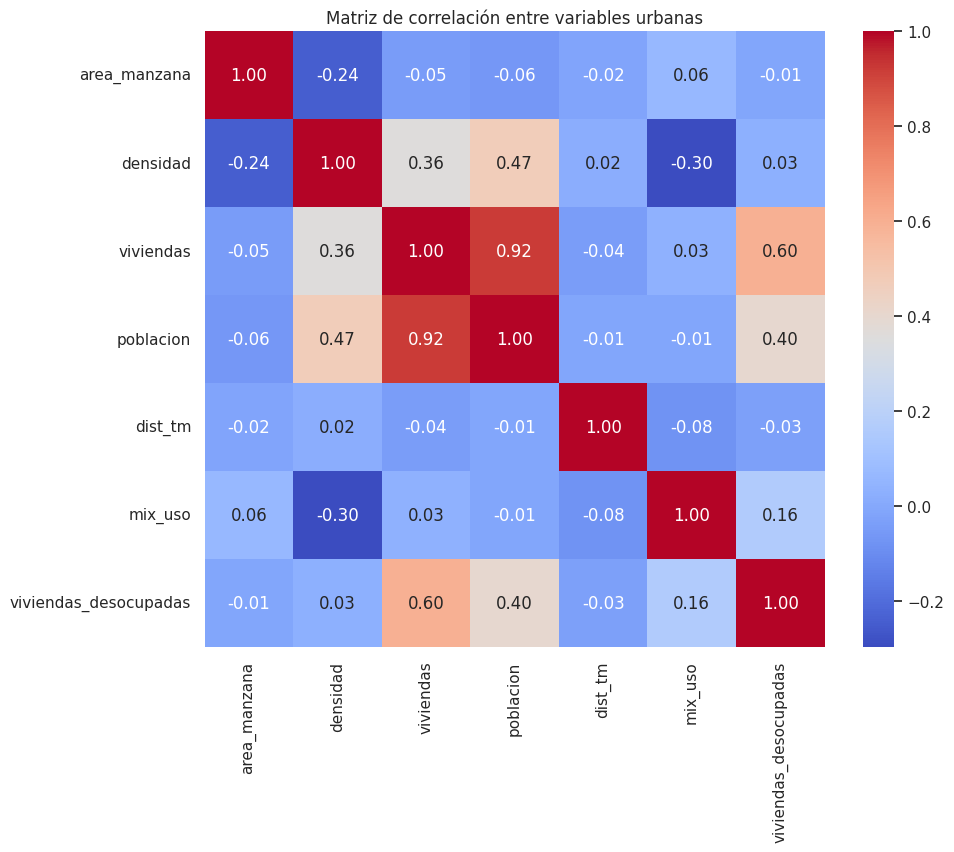

In [26]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_modelo[variables].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación entre variables urbanas")
plt.show()

### Interpretación de la matriz de correlación

La matriz de correlación permite identificar la relación lineal entre las variables urbanas utilizadas en el análisis. Se observa una correlación alta entre `poblacion` y `viviendas`, lo cual sugiere que ambas variables capturan parcialmente una misma dimensión del sistema urbano asociada a la intensidad residencial.

Por su parte, `densidad` presenta correlaciones moderadas con `poblacion` y `viviendas`, lo que indica que resume parte de esta intensidad urbana pero incorpora además el efecto del tamaño de la manzana. En contraste, `dist_tm` muestra correlaciones bajas con el resto de variables, lo cual sugiere que representa una dimensión distinta del territorio asociada a accesibilidad.

La variable `mix_uso`, construida como la suma de unidades no residenciales con uso comercial e industrial, se interpreta como un proxy de actividad económica no residencial en la manzana. Sus bajas correlaciones con las variables residenciales sugieren que aporta información complementaria al modelo.

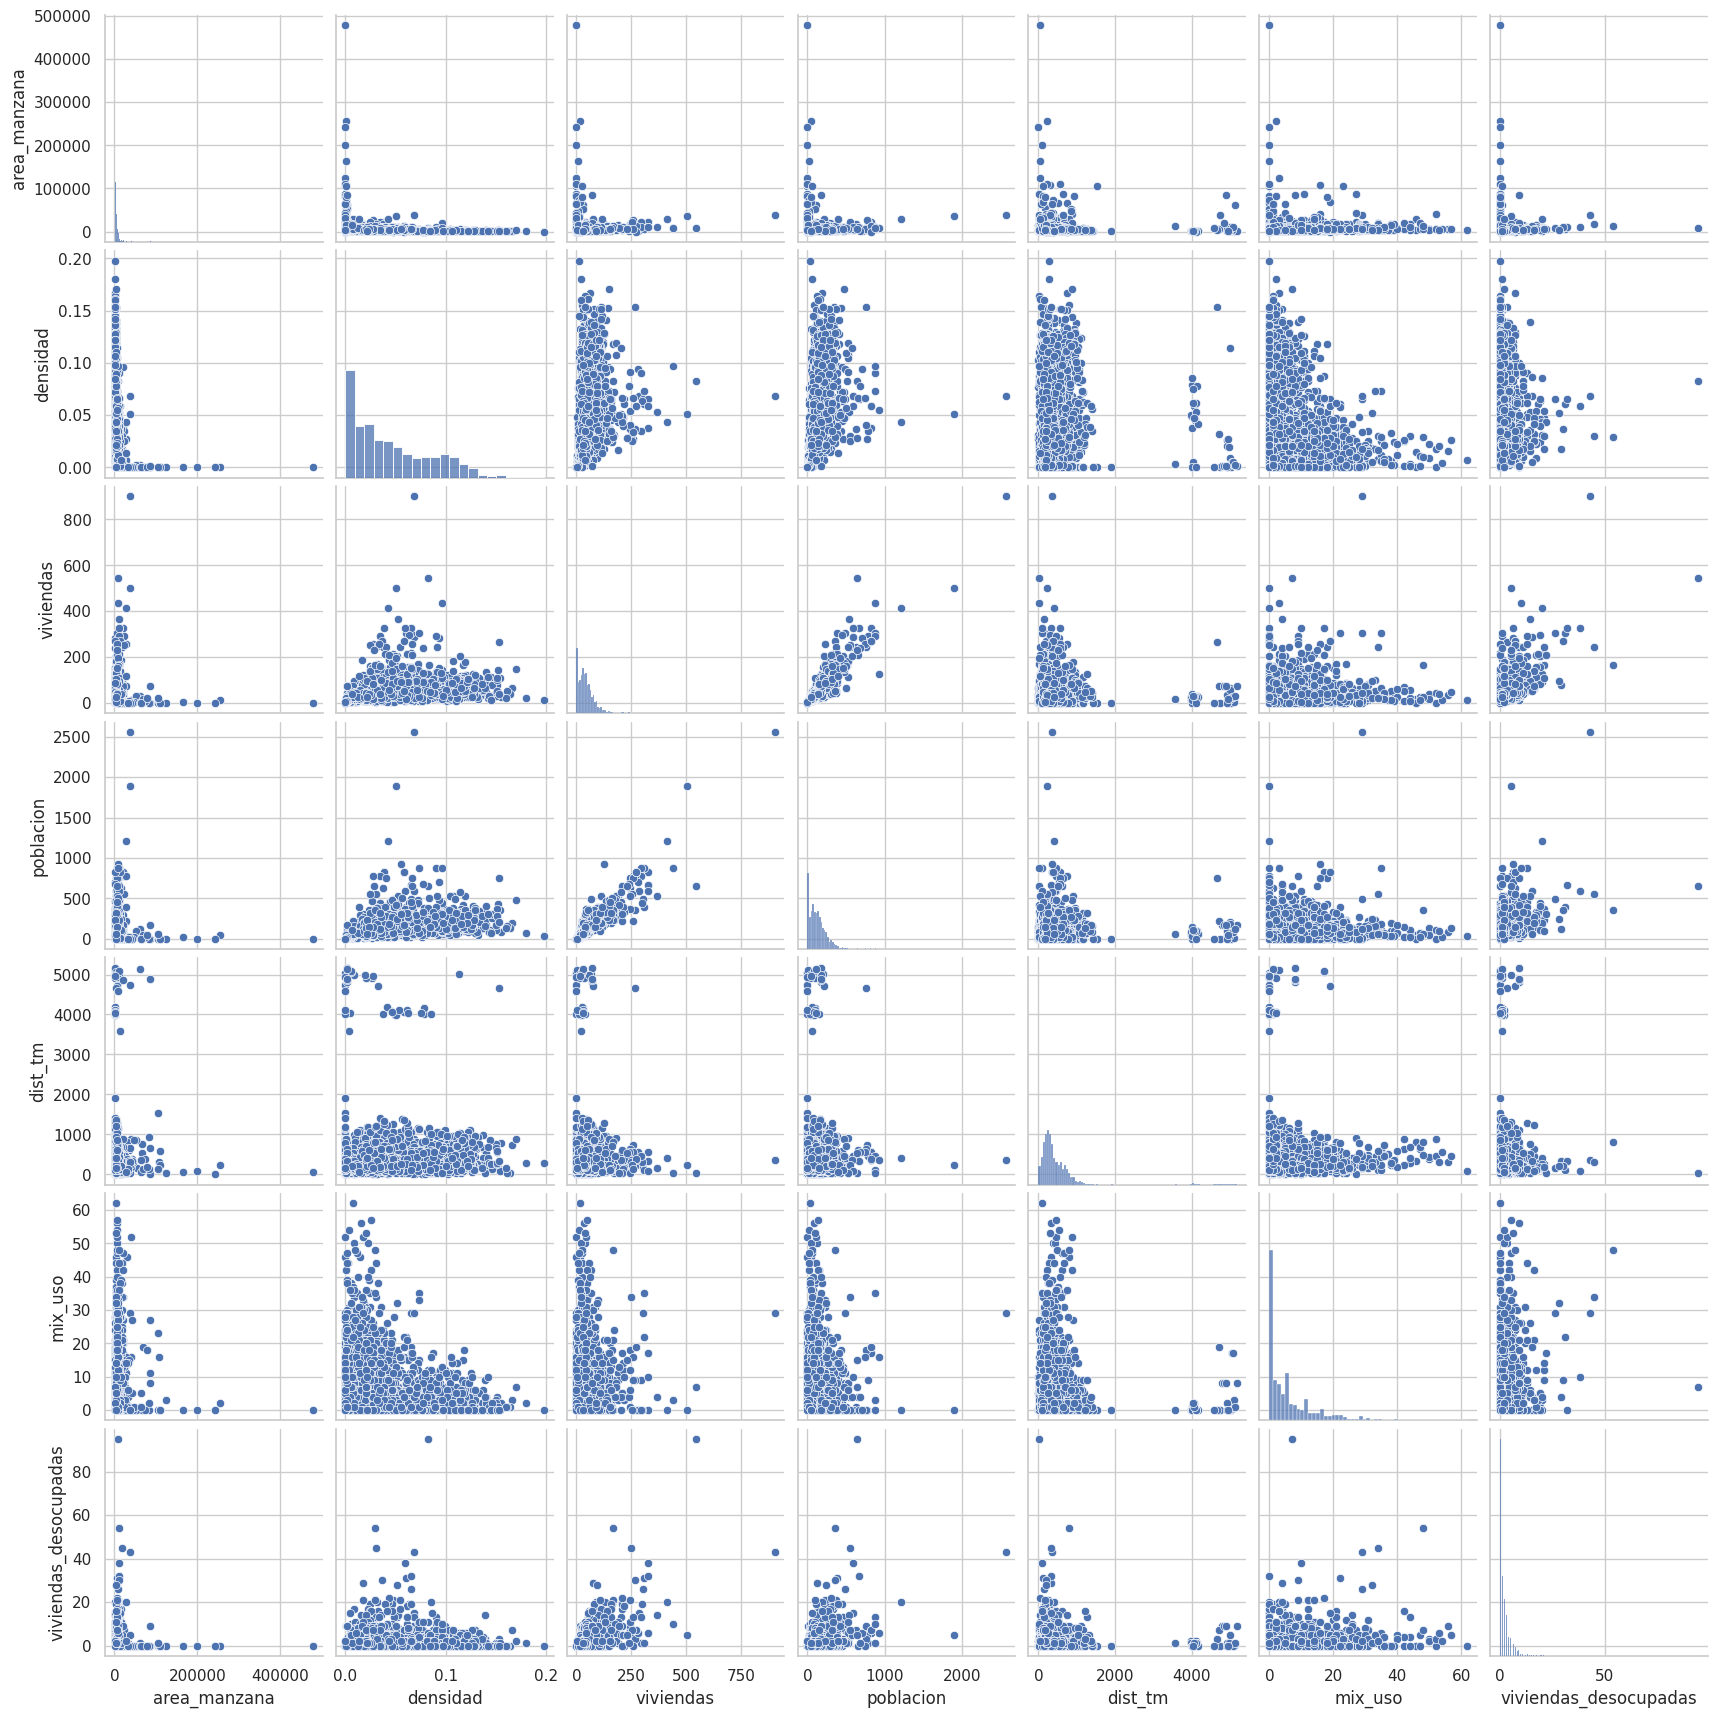

In [27]:
sns.pairplot(df_modelo[variables])
plt.show()

NORMALIZACION

## 9. Normalización de variables

Dado que las variables se encuentran en diferentes escalas y unidades (por ejemplo, metros cuadrados, personas, número de viviendas y distancias en metros), se aplica una normalización mediante StandardScaler para que ninguna variable domine el proceso de clustering.

In [28]:
X = df_modelo[variables]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Justificación de la normalización

Se aplicó una normalización mediante `StandardScaler` debido a que las variables utilizadas en el modelo presentan diferentes unidades y escalas de medición. Por ejemplo, `area_manzana` se expresa en metros cuadrados, `poblacion` en personas, `viviendas` en conteos, y `dist_tm` en metros.

Sin este proceso, variables con magnitudes numéricas más altas podrían dominar el cálculo de distancias en algoritmos como K-Means. La normalización permite que todas las variables contribuyan de manera comparable al análisis.

## 11. Método del codo

Se utiliza el método del codo para determinar el número adecuado de clusters en el algoritmo K-Means.

In [29]:
inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

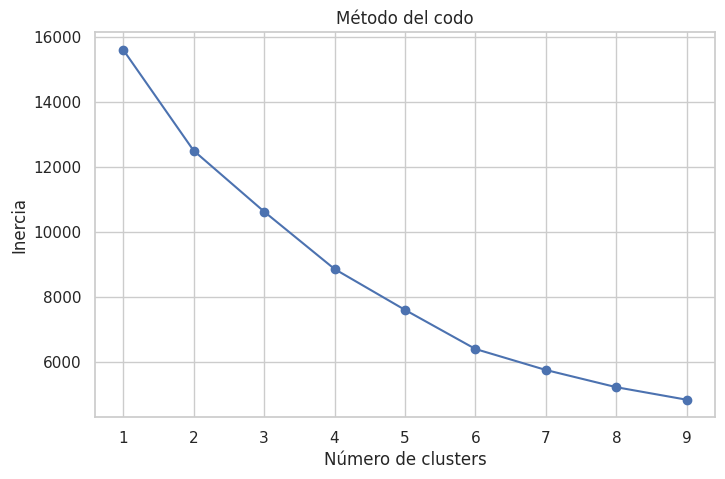

In [30]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, 10), inertia, marker="o")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.grid(True)
plt.show()

KMEANS

## 12. Clustering con K-Means

Con base en el método del codo, se define el número de clusters y se agrupan las manzanas según similitud en sus características urbanas.

In [31]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_modelo["cluster"] = kmeans.fit_predict(X_scaled)

In [32]:
df_modelo["cluster"].value_counts()

,count
cluster,
0,1201
2,954
1,73


## 13. Caracterización de tipologias urbanas mediante K-Means/Clusters

Los clusters identificados mediante el algoritmo K-Means representan tipologías urbanas de manzanas con características similares en términos de densidad, población, usos de la vivienda y accesibilidad al sistema de transporte masivo.

El objetivo del clustering no es establecer directamente la prioridad de intervención, sino identificar patrones territoriales dentro del conjunto de manzanas analizadas. Posteriormente, la priorización de renovación urbana se calcula mediante un índice de puntuación (score de renovación) construido a partir de variables urbanas relevantes.

In [33]:
df_modelo.groupby("cluster")[variables].mean().round(3)

,area_manzana,densidad,viviendas,poblacion,dist_tm,mix_uso,viviendas_desocupadas
cluster,,,,,,,
0,9101.506,0.016,24.482,63.689,411.284,8.869,1.479
1,9440.305,0.056,234.082,534.575,357.752,9.822,15.479
2,2867.105,0.081,63.647,195.904,527.243,3.037,1.832


Distribución de clusters por actuación estratégica

In [34]:
pd.crosstab(df_modelo["actuacion_estrategica"], df_modelo["cluster"])

cluster,0,1,2
actuacion_estrategica,,,
20 de Julio,35,1,14
Borde Usme,16,1,21
Calle 72,100,0,24
Campin 7 de Agosto,100,1,2
Chapinero verde e inteligente,53,23,21
Chucua La Vaca,41,1,117
Ciudadela educativa y del cuidado,32,10,149
Distrito Aeroportuario Engativá,62,5,204
Distrito Aeroportuario Fontibón,163,9,257


In [35]:
tabla_clusters_ae = pd.crosstab(
    df_modelo["actuacion_estrategica"],
    df_modelo["cluster"],
    normalize="index"
)

tabla_clusters_ae.round(2)

cluster,0,1,2
actuacion_estrategica,,,
20 de Julio,0.70,0.02,0.28
Borde Usme,0.42,0.03,0.55
Calle 72,0.81,0.00,0.19
Campin 7 de Agosto,0.97,0.01,0.02
Chapinero verde e inteligente,0.55,0.24,0.22
Chucua La Vaca,0.26,0.01,0.74
Ciudadela educativa y del cuidado,0.17,0.05,0.78
Distrito Aeroportuario Engativá,0.23,0.02,0.75
Distrito Aeroportuario Fontibón,0.38,0.02,0.60


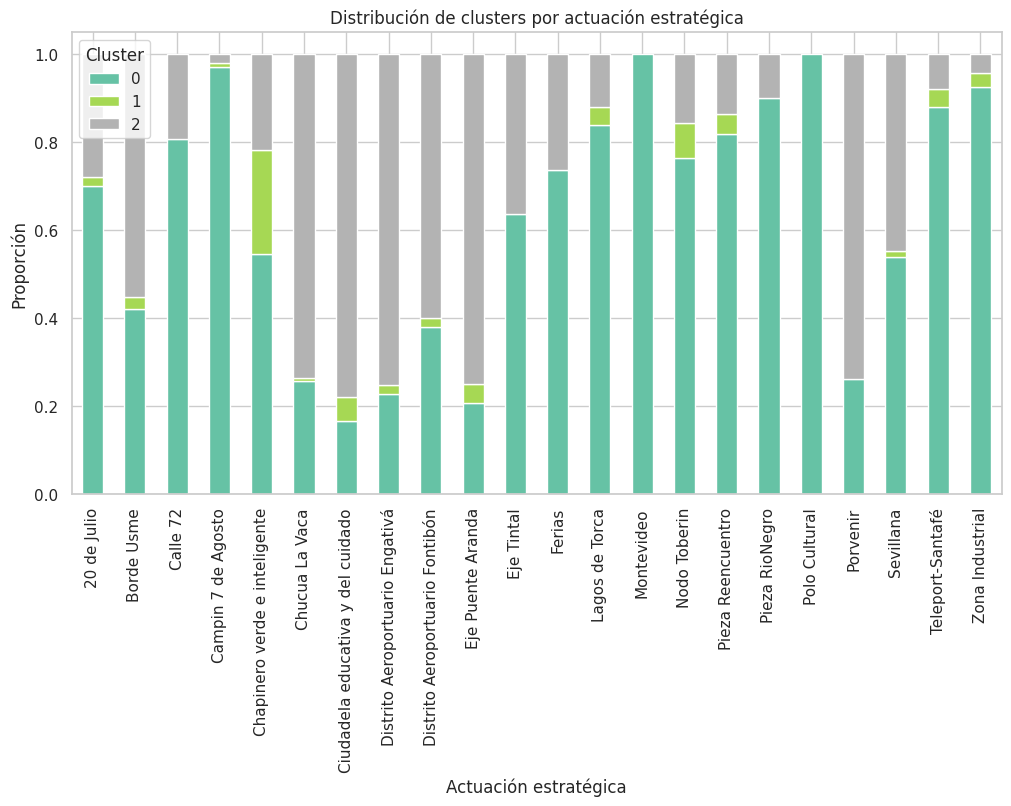

In [36]:
tabla_clusters_ae.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    colormap="Set2"
)

plt.title("Distribución de clusters por actuación estratégica")
plt.xlabel("Actuación estratégica")
plt.ylabel("Proporción")
plt.legend(title="Cluster")
plt.show()

Silhouette Score: Sirve para ver qué tan bien separados están los clusters.


In [37]:


from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, df_modelo["cluster"])

print("Silhouette score:", score)


Silhouette score: 0.28229119087869026



valor	interpretación
0.2	débil
0.3–0.5	razonable

0.5 | clusters bien definidos

En urban data normalmente sale 0.25–0.4.

Eso lo puedes escribir en el paper como:

El índice de Silhouette fue de 0.28,

# 14. Construcción del score de renovación urbana

Normalizar variables para el Score de Ronovacion

In [38]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

vars_score = [
    "viviendas_desocupadas",
    "densidad",
    "poblacion",
    "dist_tm",
    "mix_uso"
]

scaler = MinMaxScaler()

norm = scaler.fit_transform(df_modelo[vars_score])

norm = pd.DataFrame(norm, columns=[v+"_norm" for v in vars_score])

df_modelo = pd.concat([df_modelo.reset_index(drop=True), norm], axis=1)

Este score prioriza:
más viviendas desocupadas
menor densidad
menor población
cercanía a TransMilenio
actividad económica

In [39]:
df_modelo["score_renovacion"] = (
    df_modelo["viviendas_desocupadas_norm"] * 0.45 +
    (1 - df_modelo["dist_tm_norm"]) * 0.30 +
    (1 - df_modelo["densidad_norm"]) * 0.20 +
    df_modelo["mix_uso_norm"] * 0.05
)

Convertir Score en prioridad

In [40]:
q1 = df_modelo["score_renovacion"].quantile(0.33)
q2 = df_modelo["score_renovacion"].quantile(0.66)

def clasificar_prioridad(score):

    if score <= q1:
        return "baja"

    elif score <= q2:
        return "media"

    else:
        return "alta"

df_modelo["prioridad_final"] = df_modelo["score_renovacion"].apply(clasificar_prioridad)

Verificar que está OK

In [41]:
df_modelo["prioridad_final"].value_counts()

,count
prioridad_final,
alta,758
media,735
baja,735


Revisar si la prioridad es la correcta

In [42]:
df_modelo.groupby("prioridad_final")[[
    "viviendas_desocupadas",
    "densidad",
    "poblacion",
    "dist_tm"
]].mean().round(2)

,viviendas_desocupadas,densidad,poblacion,dist_tm
prioridad_final,,,,
alta,3.28,0.01,82.75,251.87
baja,1.16,0.09,183.55,718.70
media,1.79,0.04,142.55,413.47


Esto debería mostrar:

prioridad	interpretación
alta	más vacancia, menos densidad
media	valores intermedios
baja	más densidad / más población

Prioridad por AE



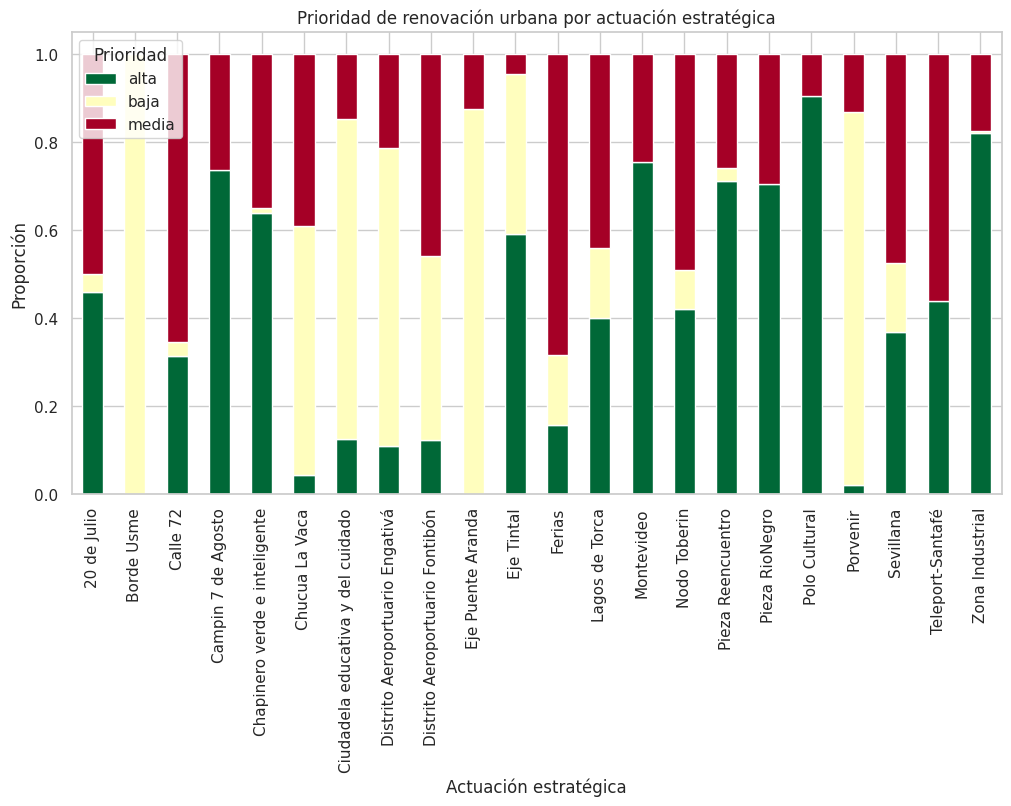

In [43]:
tabla_prioridad_ae = pd.crosstab(
    df_modelo["actuacion_estrategica"],
    df_modelo["prioridad_final"],
    normalize="index"
)

tabla_prioridad_ae.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6),
    colormap="RdYlGn_r"
)

plt.title("Prioridad de renovación urbana por actuación estratégica")
plt.xlabel("Actuación estratégica")
plt.ylabel("Proporción")
plt.legend(title="Prioridad")

plt.show()

Validación del score

In [44]:
df_modelo.groupby("prioridad_final")[[
    "viviendas_desocupadas",
    "densidad",
    "poblacion",
    "dist_tm"
]].mean().round(2)



,viviendas_desocupadas,densidad,poblacion,dist_tm
prioridad_final,,,,
alta,3.28,0.01,82.75,251.87
baja,1.16,0.09,183.55,718.70
media,1.79,0.04,142.55,413.47


In [45]:
df_modelo.columns

Index(['objectid', 'man_codigo', 'actuacion_estrategica', 'ae_priorizada',
       'cod_dane', 'area_manzana', 'densidad', 'viviendas', 'poblacion',
       'dist_tm', 'mix_uso', 'cantidad_encuestas', 'uso_residencial',
       'uso_industrial', 'uso_comercial', 'viviendas_desocupadas',
       'tiene_parque', 'tiene_equipa_pub', 'tiene_esp_pub', 'tiene_aim',
       'plan_parcial_excluido', 'estado_pp', 'tiene_bic', 'sum_exclusiones',
       'calificables', 'cluster', 'viviendas_desocupadas_norm',
       'densidad_norm', 'poblacion_norm', 'dist_tm_norm', 'mix_uso_norm',
       'score_renovacion', 'prioridad_final'],
      dtype='object')

In [46]:
df_modelo.head()

,objectid,man_codigo,actuacion_estrategica,ae_priorizada,cod_dane,area_manzana,densidad,viviendas,poblacion,dist_tm,...,sum_exclusiones,calificables,cluster,viviendas_desocupadas_norm,densidad_norm,poblacion_norm,dist_tm_norm,mix_uso_norm,score_renovacion,prioridad_final
0,1,8544012,Lagos de Torca,0,1100110000000085330115,9850.528979,0.048472,190.0,492.0,211.750049,...,0.0,1.0,1,0.010526,0.244870,0.192112,0.040934,0.177419,0.452354,media
1,2,8519059,Nodo Toberin,0,1100110000000085190312,3952.997481,0.013165,20.0,52.0,826.160220,...,0.0,1.0,0,0.021053,0.066506,0.020305,0.159708,0.016129,0.449067,media
2,3,8516029,Nodo Toberin,0,1100110000000085160107,6712.437990,0.027434,50.0,184.0,773.151617,...,0.0,1.0,0,0.021053,0.138590,0.071847,0.149461,0.080645,0.440950,media
3,4,8516019,Nodo Toberin,0,1100110000000085160201,21563.511592,0.038000,325.0,822.0,567.918018,...,0.0,1.0,1,0.063158,0.191969,0.320968,0.109786,0.274194,0.470801,media
4,5,8501008,Nodo Toberin,0,1100110000000085010206,17517.294260,0.005901,47.0,100.0,238.909162,...,0.0,1.0,0,0.000000,0.029810,0.039047,0.046184,0.612903,0.510828,alta


In [47]:
columnas_finales = [
    "man_codigo",
    "actuacion_estrategica",
    "viviendas_desocupadas",
    "densidad",
    "poblacion",
    "dist_tm",
    "mix_uso",
    "score_renovacion",
    "prioridad_final"
]

df_modelo[columnas_finales].to_excel("resultado_priorizacion_final.xlsx", index=False)

Excel
En arcgis y todo prioridad_final para interpretar

In [48]:
df_modelo.to_excel("resultado_priorizacion_final.xlsx", index=False)

# 15. Resultados del modelo de priorización

In [49]:
df_modelo["prioridad_final"].value_counts()

,count
prioridad_final,
alta,758
media,735
baja,735


In [50]:
df_modelo["prioridad_final"].value_counts(normalize=True).round(3) * 100

,proportion
prioridad_final,
alta,34.0
media,33.0
baja,33.0


In [51]:
df_modelo.groupby("prioridad_final")[[
    "viviendas_desocupadas",
    "densidad",
    "poblacion",
    "dist_tm",
    "mix_uso"
]].mean().round(2)

,viviendas_desocupadas,densidad,poblacion,dist_tm,mix_uso
prioridad_final,,,,,
alta,3.28,0.01,82.75,251.87,11.23
baja,1.16,0.09,183.55,718.70,2.47
media,1.79,0.04,142.55,413.47,5.36


In [52]:
df_modelo["score_renovacion"].describe().round(3)

,score_renovacion
count,2228.000
mean,0.443
std,0.060
min,0.088
25%,0.406
50%,0.456
75%,0.485
max,0.871


In [53]:
tabla_prioridad_ae = pd.crosstab(
    df_modelo["actuacion_estrategica"],
    df_modelo["prioridad_final"],
    normalize="index"
)

tabla_prioridad_ae.round(2)

prioridad_final,alta,baja,media
actuacion_estrategica,,,
20 de Julio,0.46,0.04,0.50
Borde Usme,0.00,1.00,0.00
Calle 72,0.31,0.03,0.65
Campin 7 de Agosto,0.74,0.00,0.26
Chapinero verde e inteligente,0.64,0.01,0.35
Chucua La Vaca,0.04,0.57,0.39
Ciudadela educativa y del cuidado,0.13,0.73,0.15
Distrito Aeroportuario Engativá,0.11,0.68,0.21
Distrito Aeroportuario Fontibón,0.12,0.42,0.46


Scatter de resultados del modelo

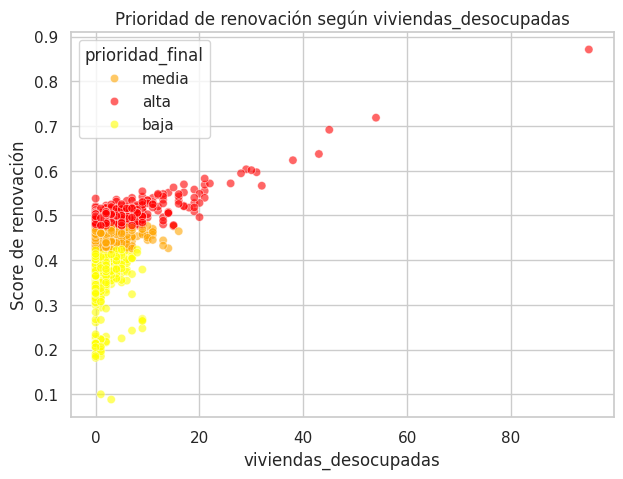

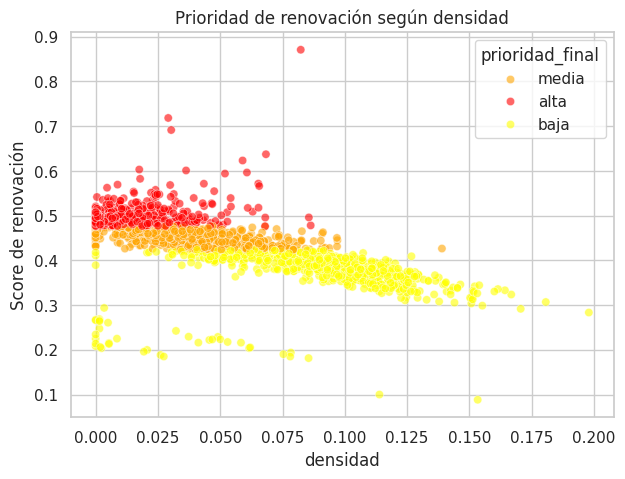

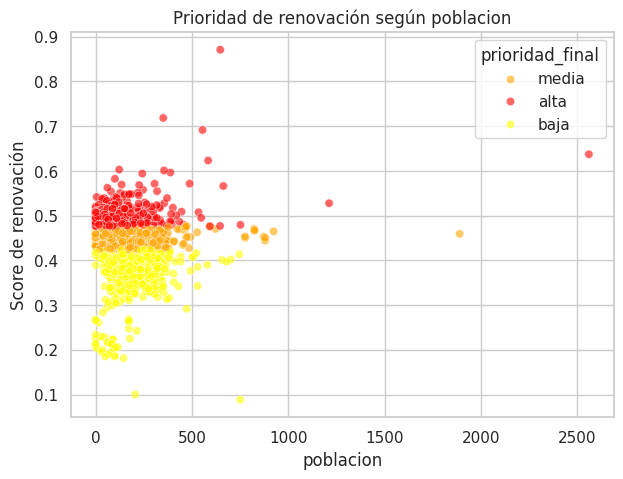

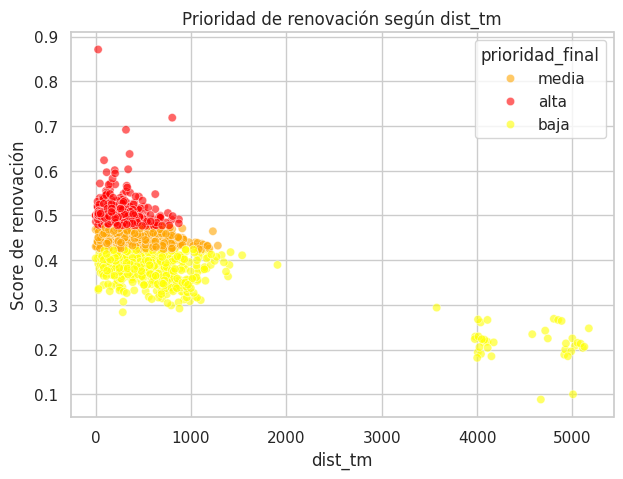

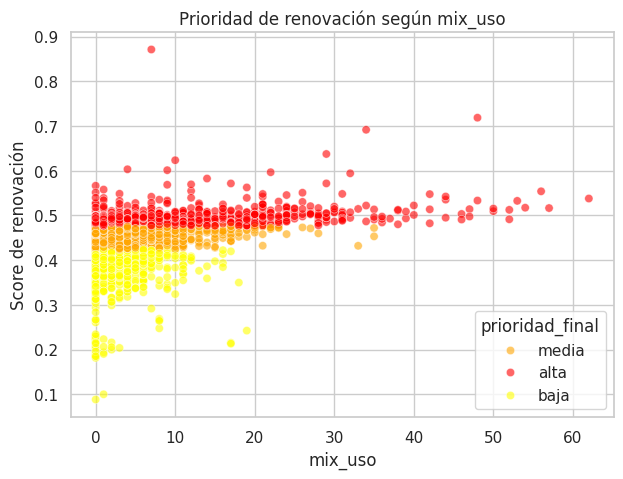

In [54]:

variables = [
    "viviendas_desocupadas",
    "densidad",
    "poblacion",
    "dist_tm",
    "mix_uso"
]

for var in variables:

    plt.figure(figsize=(7,5))

    sns.scatterplot(
        data=df_modelo,
        x=var,
        y="score_renovacion",
        hue="prioridad_final",
        palette={"alta":"red","media":"orange","baja":"yellow"},
        alpha=0.6
    )

    plt.title(f"Prioridad de renovación según {var}")
    plt.xlabel(var)
    plt.ylabel("Score de renovación")

    plt.show()


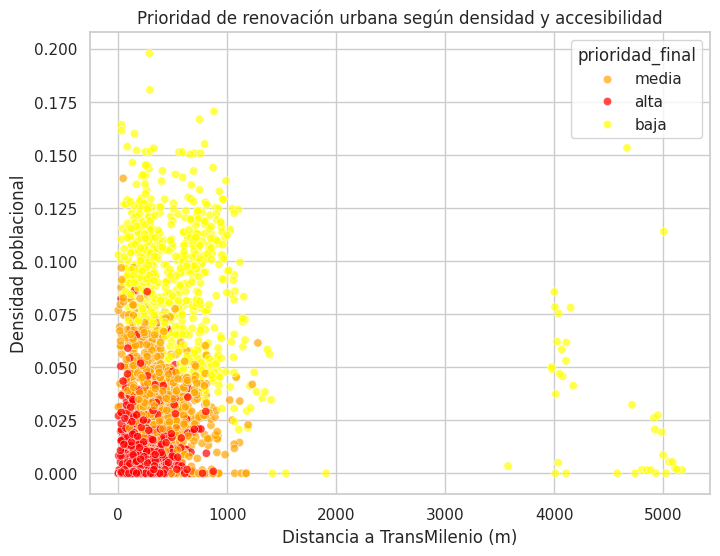

In [55]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_modelo,
    x="dist_tm",
    y="densidad",
    hue="prioridad_final",
    palette={"alta":"red","media":"orange","baja":"yellow"},
    alpha=0.7
)

plt.title("Prioridad de renovación urbana según densidad y accesibilidad")
plt.xlabel("Distancia a TransMilenio (m)")
plt.ylabel("Densidad poblacional")

palette={
"alta":"#d73027",
"media":"#fdae61",
"baja":"#fee08b"
}

plt.show()

La figura muestra la distribución de las manzanas según densidad poblacional y distancia al sistema de transporte masivo. Los colores representan la prioridad de renovación urbana asignada por el modelo. Se observa que las manzanas clasificadas con prioridad alta tienden a concentrarse en áreas con menor densidad poblacional y buena accesibilidad al transporte, lo cual coincide con el objetivo del modelo de identificar zonas con mayor potencial de intervención y menor impacto en términos de desplazamiento de población

Box Plot por prioridad

/tmp/ipykernel_3119/523603989.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3119/523603989.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3119/523603989.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3119/523603989.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_3119/523603989.py:15: FutureWarning: 

Passin

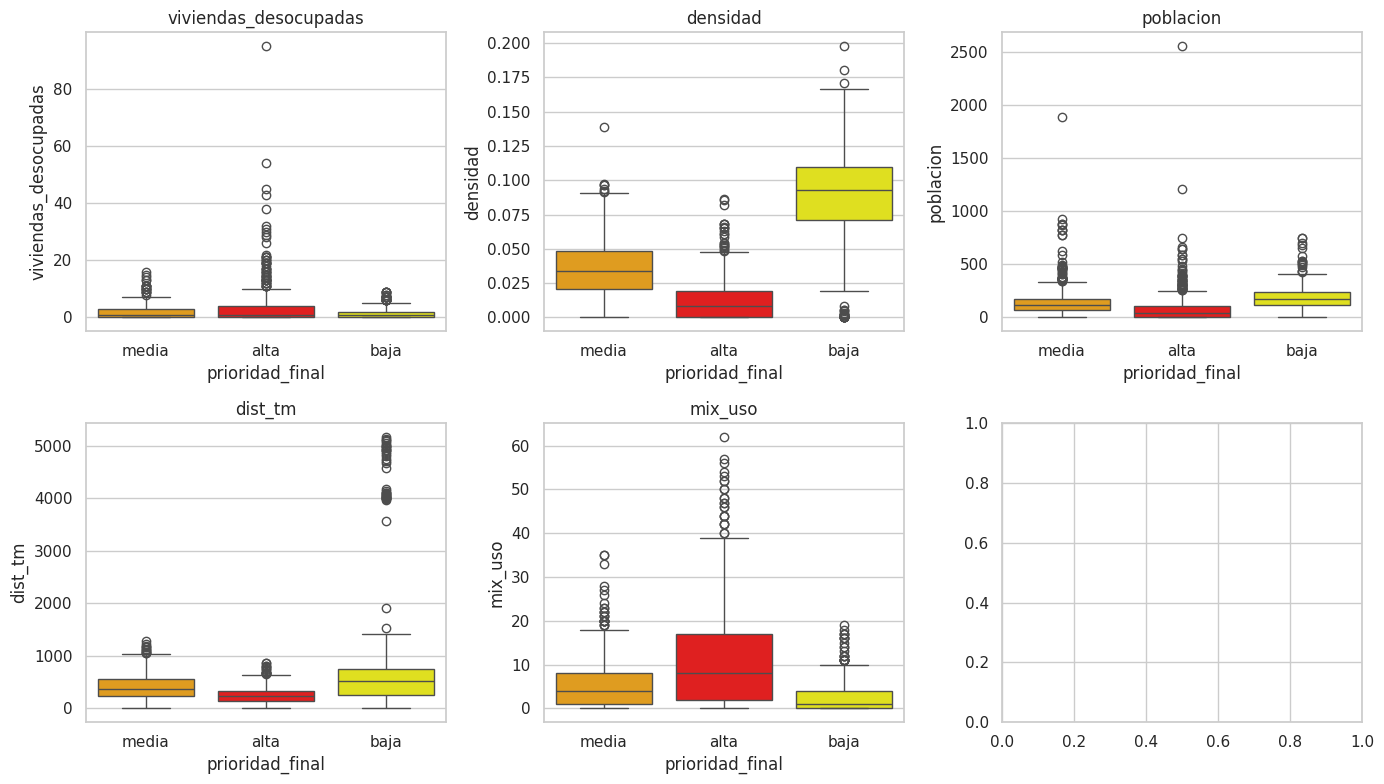

In [56]:
variables = [
    "viviendas_desocupadas",
    "densidad",
    "poblacion",
    "dist_tm",
    "mix_uso"
]

fig, axes = plt.subplots(2,3, figsize=(14,8))

axes = axes.flatten()

for i, var in enumerate(variables):

    sns.boxplot(
        data=df_modelo,
        x="prioridad_final",
        y=var,
        palette={"alta":"red","media":"orange","baja":"yellow"},
        ax=axes[i]
    )

    axes[i].set_title(var)

plt.tight_layout()
plt.show()



/tmp/ipykernel_3119/149542101.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


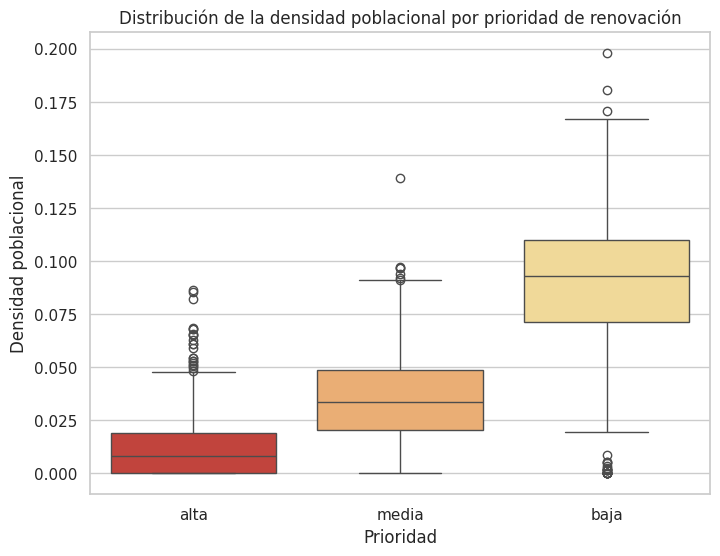

In [57]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df_modelo,
    x="prioridad_final",
    y="densidad",
    order=["alta","media","baja"],
    palette={"alta":"#d73027","media":"#fdae61","baja":"#fee08b"}
)

plt.title("Distribución de la densidad poblacional por prioridad de renovación")
plt.xlabel("Prioridad")
plt.ylabel("Densidad poblacional")
plt.show()



/tmp/ipykernel_3119/3826201388.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


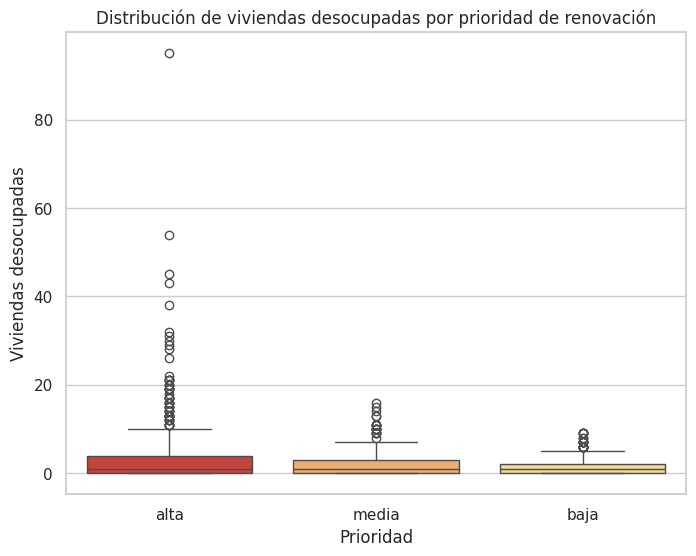

In [58]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df_modelo,
    x="prioridad_final",
    y="viviendas_desocupadas",
    order=["alta","media","baja"],
    palette={"alta":"#d73027","media":"#fdae61","baja":"#fee08b"}
)

plt.title("Distribución de viviendas desocupadas por prioridad de renovación")
plt.xlabel("Prioridad")
plt.ylabel("Viviendas desocupadas")
plt.show()


Hitograma del Score

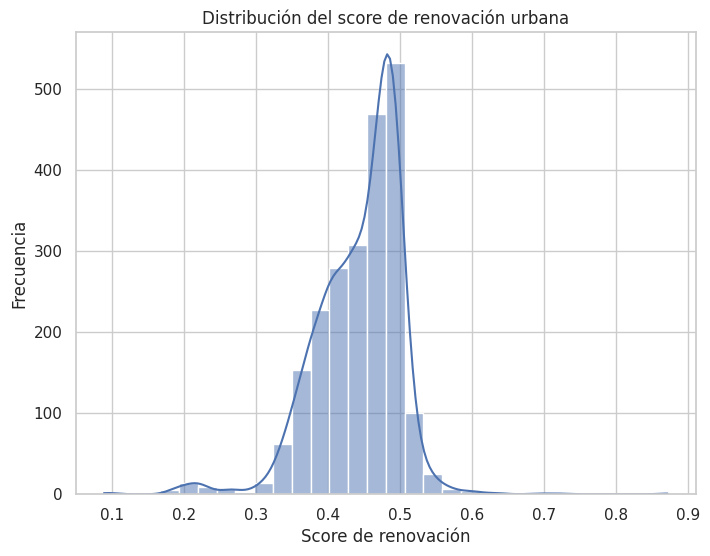

In [59]:
plt.figure(figsize=(8,6))

sns.histplot(
    data=df_modelo,
    x="score_renovacion",
    bins=30,
    kde=True
)

plt.title("Distribución del score de renovación urbana")
plt.xlabel("Score de renovación")
plt.ylabel("Frecuencia")
plt.show()


Promedio de variable



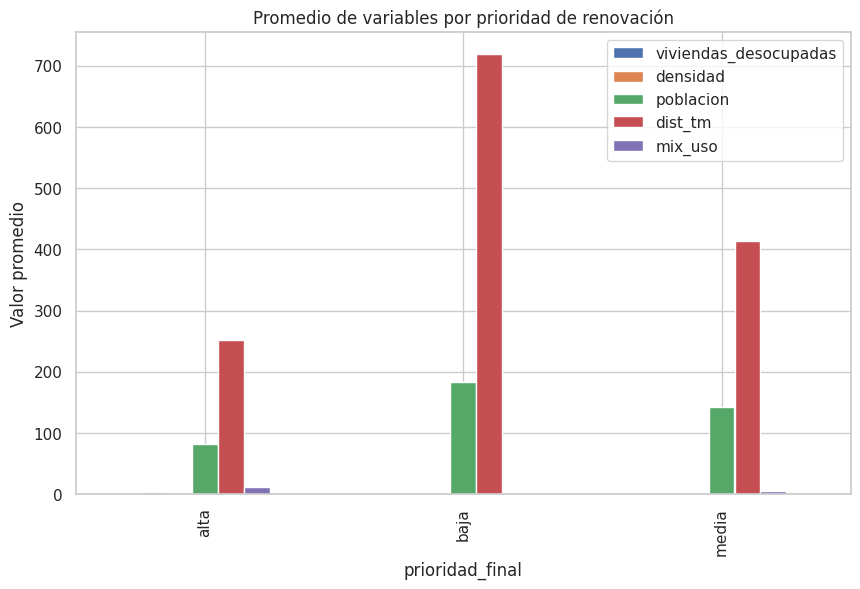

In [60]:
tabla = df_modelo.groupby("prioridad_final")[[
    "viviendas_desocupadas",
    "densidad",
    "poblacion",
    "dist_tm",
    "mix_uso"
]].mean()

tabla.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Promedio de variables por prioridad de renovación")
plt.ylabel("Valor promedio")

plt.show()


In [61]:
tabla_resultados = df_modelo.groupby("prioridad_final")[[
    "viviendas_desocupadas",
    "densidad",
    "poblacion",
    "dist_tm",
    "mix_uso"
]].mean().round(2)

tabla_resultados


,viviendas_desocupadas,densidad,poblacion,dist_tm,mix_uso
prioridad_final,,,,,
alta,3.28,0.01,82.75,251.87,11.23
baja,1.16,0.09,183.55,718.70,2.47
media,1.79,0.04,142.55,413.47,5.36


In [62]:
df_modelo[[
    "score_renovacion",
    "viviendas_desocupadas",
    "densidad",
    "poblacion",
    "dist_tm",
    "mix_uso"
]].corr()


,score_renovacion,viviendas_desocupadas,densidad,poblacion,dist_tm,mix_uso
score_renovacion,1.000000,0.357530,-0.708572,-0.172085,-0.611377,0.414509
viviendas_desocupadas,0.357530,1.000000,0.029631,0.398581,-0.030428,0.160428
densidad,-0.708572,0.029631,1.000000,0.468248,0.020348,-0.298416
poblacion,-0.172085,0.398581,0.468248,1.000000,-0.013589,-0.009329
dist_tm,-0.611377,-0.030428,0.020348,-0.013589,1.000000,-0.076318
mix_uso,0.414509,0.160428,-0.298416,-0.009329,-0.076318,1.000000


<Axes: xlabel='prioridad_final', ylabel='score_renovacion'>

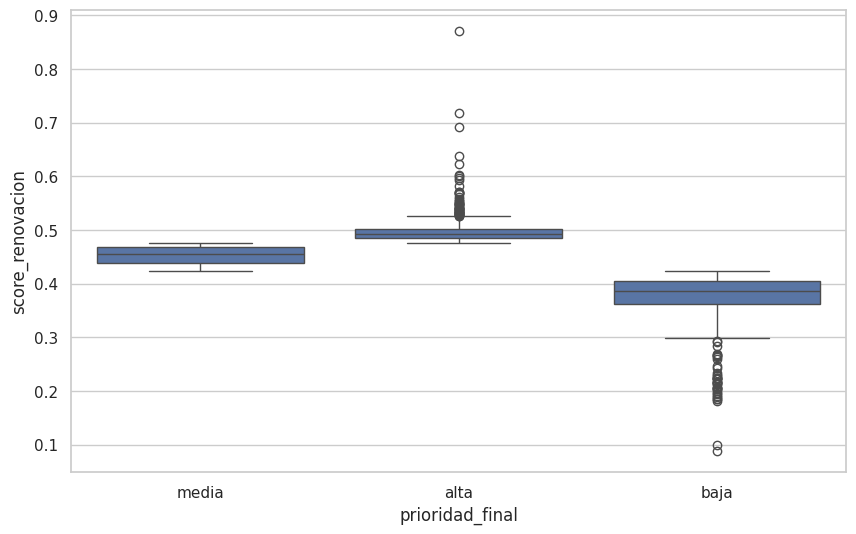

In [63]:
sns.boxplot(
    data=df_modelo,
    x="prioridad_final",
    y="score_renovacion"
)


In [64]:
df_modelo["prioridad_final"].value_counts()

,count
prioridad_final,
alta,758
media,735
baja,735


In [65]:
df_modelo.groupby("prioridad_final")[[    "viviendas_desocupadas",    "densidad",    "poblacion",    "dist_tm",    "mix_uso"]].mean()

,viviendas_desocupadas,densidad,poblacion,dist_tm,mix_uso
prioridad_final,,,,,
alta,3.284960,0.012466,82.745383,251.865571,11.230871
baja,1.156463,0.088929,183.551020,718.695693,2.472109
media,1.787755,0.035335,142.552381,413.472310,5.355102
